Compute Historical VaR (95%) for each fund: VaR = 5th percentile of
daily return distribution CVaR = mean of returns below VaR threshold

In [1]:
import pandas as pd
import numpy as np

In [2]:
nav = pd.read_csv("../data/processed/clean_nav.csv")

print(nav.shape)
print(nav.head())
print(nav.dtypes)

(46000, 3)
   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
amfi_code      int64
date             str
nav          float64
dtype: object


In [3]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

print(nav.head())
print(nav.dtypes)

   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639
amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object


In [4]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()
print(nav.head(10))

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073


In [5]:
var_cvar = []

for fund, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    # VaR at 95% confidence = 5th percentile
    var_95 = np.percentile(returns, 5)

    # CVaR = mean of returns below or equal to VaR threshold
    cvar_95 = returns[returns <= var_95].mean()

    var_cvar.append({
        "amfi_code": fund,
        "VaR_95": var_95,
        "CVaR_95": cvar_95
    })

var_cvar_report = pd.DataFrame(var_cvar)

print(var_cvar_report)

    amfi_code    VaR_95   CVaR_95
0      100016 -0.014364 -0.018060
1      100025 -0.003793 -0.004994
2      100033 -0.019034 -0.023456
3      101206 -0.013282 -0.017439
4      101207 -0.026021 -0.032459
5      101208 -0.000269 -0.000422
6      102885 -0.012613 -0.015490
7      102886 -0.019220 -0.023251
8      102887 -0.015232 -0.019411
9      118632 -0.013954 -0.017619
10     118633 -0.013443 -0.016630
11     118634 -0.025438 -0.032304
12     118635 -0.012554 -0.016177
13     118636 -0.003804 -0.004919
14     119092 -0.013750 -0.017328
15     119093 -0.014226 -0.017487
16     119094 -0.018480 -0.024260
17     119095 -0.026188 -0.031667
18     119120 -0.003938 -0.005014
19     119551 -0.012846 -0.016397
20     119552 -0.013501 -0.017336
21     119598 -0.024507 -0.030595
22     119599 -0.026859 -0.032384
23     120503 -0.013550 -0.017451
24     120504 -0.013728 -0.017494
25     120505 -0.018892 -0.024342
26     120506 -0.014388 -0.019405
27     120507 -0.000222 -0.000373
28     120841 

In [45]:
var_cvar_report.sort_values("VaR_95").head(5)

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595


In [ ]:
var_cvar_report.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv created successfully")

var_cvar_report.csv created successfully


Compute Rolling 90-day Sharpe Ratio for 5 funds: rolling_sharpe =
returns.rolling(90).mean() / returns.rolling(90).std() * sqrt(252)
Plot over time

In [7]:
five_funds = [119551, 120503, 118632, 119092, 120841]

sharpe_data = nav[nav["amfi_code"].isin(five_funds)].copy()

print(sharpe_data["amfi_code"].unique())

[118632 119092 119551 120503 120841]


In [8]:
sharpe_data["rolling_sharpe"] = (
    sharpe_data.groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).mean() /
               x.rolling(90).std() * np.sqrt(252))
)

print(sharpe_data[["amfi_code", "date", "rolling_sharpe"]].tail(10))

       amfi_code       date  rolling_sharpe
33340     120841 2026-05-18        1.743906
33341     120841 2026-05-19        1.902434
33342     120841 2026-05-20        2.035416
33343     120841 2026-05-21        2.141182
33344     120841 2026-05-22        2.148822
33345     120841 2026-05-25        2.427230
33346     120841 2026-05-26        2.355138
33347     120841 2026-05-27        2.240101
33348     120841 2026-05-28        2.324704
33349     120841 2026-05-29        2.167518


In [47]:
sharpe_data.groupby("amfi_code")["rolling_sharpe"].max().sort_values(ascending=False)

amfi_code
120841    6.769155
119551    6.446039
118632    5.265426
120503    5.010124
119092    4.766055
Name: rolling_sharpe, dtype: float64

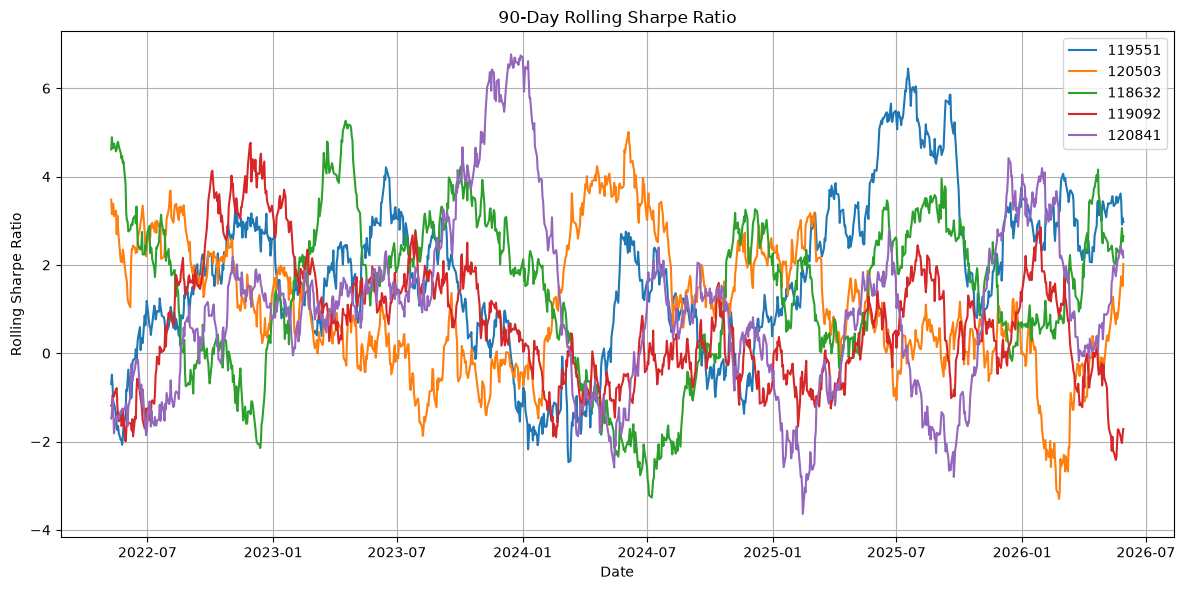

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for fund in five_funds:
    fund_data = sharpe_data[sharpe_data["amfi_code"] == fund]

    plt.plot(
        fund_data["date"],
        fund_data["rolling_sharpe"],
        label=str(fund)
    )

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("../reports/charts/rolling_sharpe_chart.png", dpi=300)
plt.show()

Investor cohort analysis: Group investors by first transaction year
(2024/2025) Compute average SIP amount, total invested, fund
preference by cohort

In [10]:
transactions = pd.read_csv("../data/processed/clean_transactions.csv")

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

print(transactions.shape)
print(transactions.head())
print(transactions.columns.tolist())

(32778, 13)
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female                54.4   
4        Delhi      Noida       T30     26-35    Male                14.5   

  payment_mode kyc_status  
0          UPI   Verified  
1       Cheque   Verifie

In [11]:
print(transactions.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


In [12]:
first_transaction = (
    transactions.groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_transaction["cohort_year"] = (
    first_transaction["transaction_date"].dt.year
)

print(first_transaction.head())

  investor_id transaction_date  cohort_year
0   INV000001       2024-11-04         2024
1   INV000002       2024-03-29         2024
2   INV000003       2024-07-16         2024
3   INV000004       2024-03-16         2024
4   INV000005       2024-04-27         2024


In [13]:
transactions = transactions.merge(
    first_transaction[["investor_id", "cohort_year"]],
    on="investor_id",
    how="left"
)

print(transactions[[
    "investor_id",
    "transaction_date",
    "transaction_type",
    "amount_inr",
    "amfi_code",
    "cohort_year"
]].head())

  investor_id transaction_date transaction_type  amount_inr  amfi_code  \
0   INV003054       2024-01-01              SIP        1834     119092   
1   INV002952       2024-01-01       Redemption      392882     148567   
2   INV003420       2024-01-01              SIP         912     118636   
3   INV003436       2024-01-01              SIP        1102     118634   
4   INV004691       2024-01-01          Lumpsum        8682     119094   

   cohort_year  
0         2024  
1         2024  
2         2024  
3         2024  
4         2024  


In [14]:
cohort_data = transactions[
    transactions["cohort_year"].isin([2024, 2025])
]

cohort_summary = (
    cohort_data.groupby("cohort_year")
    .agg(
        average_sip_amount=(
            "amount_inr",
            lambda x: x[cohort_data.loc[x.index, "transaction_type"] == "SIP"].mean()
        ),
        total_invested=("amount_inr", "sum")
    )
    .reset_index()
)

print(cohort_summary)

   cohort_year  average_sip_amount  total_invested
0         2024        10996.885825      3491125187
1         2025        13505.209581        30455243


In [15]:
fund_preference = (
    transactions[
        transactions["cohort_year"].isin([2024, 2025])
    ]
    .groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="transaction_count")
)

fund_preference = fund_preference.sort_values(
    ["cohort_year", "transaction_count"],
    ascending=[True, False]
)

print(fund_preference)

    cohort_year  amfi_code  transaction_count
35         2024     148568                874
33         2024     125498                869
24         2024     120504                864
17         2024     119095                857
13         2024     118636                850
..          ...        ...                ...
40         2025     100016                  4
65         2025     120505                  4
41         2025     100025                  3
48         2025     102887                  3
61         2025     119598                  3

[80 rows x 3 columns]


In [22]:
cohort_pivot = fund_preference.pivot(
    index="amfi_code",
    columns="cohort_year",
    values="transaction_count"
)

print(cohort_pivot)

cohort_year  2024  2025
amfi_code              
100016        830     4
100025        791     3
100033        781     7
101206        803     8
101207        844     9
101208        832     8
102885        827     6
102886        805    10
102887        822     3
118632        811     8
118633        815     6
118634        769     7
118635        812     8
118636        850     6
119092        824     6
119093        787     8
119094        840     6
119095        857     6
119120        769     9
119551        847     8
119552        800     5
119598        739     3
119599        792    12
120503        770     9
120504        864     6
120505        777     4
120506        819     9
120507        812    12
120841        744     7
120842        818     5
120843        824     8
120844        824     9
125497        840     6
125498        869     8
148567        804     6
148568        874     9
148569        788     6
149322        814     5
149323        795     8
149324        81

In [24]:
cohort_preference = fund_preference.groupby("cohort_year").apply(
    lambda x: x.loc[x["transaction_count"].idxmax()]
).reset_index(drop=True)

print(cohort_preference)

   amfi_code  transaction_count
0     148568                874
1     119599                 12


In [25]:
cohort_preference = fund_preference.groupby("cohort_year").apply(
    lambda x: x.loc[x["transaction_count"].idxmax()]
).reset_index(drop=True)

print(cohort_preference)

   amfi_code  transaction_count
0     148568                874
1     119599                 12


In [27]:
cohort_preference = (
    fund_preference.sort_values(
        ["cohort_year", "transaction_count"],
        ascending=[True, False]
    )
    .groupby("cohort_year")
    .first()
    .reset_index()
)

print(cohort_preference)

   cohort_year  amfi_code  transaction_count
0         2024     148568                874
1         2025     119599                 12


In [28]:
cohort_analysis = cohort_summary.merge(
    cohort_preference[["cohort_year", "amfi_code", "transaction_count"]],
    on="cohort_year",
    how="left"
)

cohort_analysis = cohort_analysis.rename(
    columns={
        "amfi_code": "preferred_fund",
        "transaction_count": "preferred_fund_transaction_count"
    }
)

print(cohort_analysis)

   cohort_year  average_sip_amount  total_invested  preferred_fund  \
0         2024        10996.885825      3491125187          148568   
1         2025        13505.209581        30455243          119599   

   preferred_fund_transaction_count  
0                               874  
1                                12  


In [29]:
cohort_analysis.to_csv(
    "../data/processed/cohort_analysis.csv",
    index=False
)

print("cohort_analysis.csv created successfully")

cohort_analysis.csv created successfully


SIP continuation analysis: For each investor with 6+ SIP transactions compute average gap between transactions. Flag investors with gaps > 35 days as 'at-risk

In [17]:
sip_transactions = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

sip_transactions = sip_transactions.sort_values(
    ["investor_id", "transaction_date"]
)

print(sip_transactions.shape)
print(sip_transactions.head())

(19716, 14)
      investor_id transaction_date  amfi_code transaction_type  amount_inr  \
19621   INV000001       2024-11-04     120505              SIP       44856   
24448   INV000001       2025-01-19     125497              SIP        3090   
5650    INV000002       2024-03-29     149322              SIP        2830   
16803   INV000002       2024-09-21     120841              SIP        2354   
31881   INV000002       2025-05-17     119094              SIP        2690   

             state      city city_tier age_group gender  annual_income_lakh  \
19621      Haryana  Gurugram       T30     36-45   Male                19.9   
24448      Haryana  Gurugram       T30     36-45   Male                19.9   
5650   Maharashtra      Pune       T30     46-55   Male                24.0   
16803  Maharashtra      Pune       T30     46-55   Male                24.0   
31881  Maharashtra      Pune       T30     46-55   Male                24.0   

      payment_mode kyc_status  cohort_year  

In [ ]:
sip_counts = (
    sip_transactions
    .groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

eligible_investors = sip_counts[
    sip_counts["sip_count"] >= 6
]

print("Total eligible investors:", len(eligible_investors))
print(eligible_investors.head())

In [18]:
sip_counts = (
    sip_transactions
    .groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

eligible_investors = sip_counts[
    sip_counts["sip_count"] >= 6
]

print("Total eligible investors:", len(eligible_investors))
print(eligible_investors.head())

Total eligible investors: 1362
   investor_id  sip_count
3    INV000004          6
7    INV000008          6
9    INV000010          6
10   INV000011          7
11   INV000012          8


In [19]:
sip_transactions["sip_gap_days"] = (
    sip_transactions
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

print(
    sip_transactions[
        ["investor_id", "transaction_date", "sip_gap_days"]
    ].head(15)
)

      investor_id transaction_date  sip_gap_days
19621   INV000001       2024-11-04           NaN
24448   INV000001       2025-01-19          76.0
5650    INV000002       2024-03-29           NaN
16803   INV000002       2024-09-21         176.0
31881   INV000002       2025-05-17         238.0
12652   INV000003       2024-07-16           NaN
27622   INV000003       2025-03-11         238.0
4773    INV000004       2024-03-16           NaN
6418    INV000004       2024-04-11          26.0
8271    INV000004       2024-05-09          28.0
12003   INV000004       2024-07-07          59.0
28749   INV000004       2025-03-29         265.0
31897   INV000004       2025-05-17          49.0
16326   INV000005       2024-09-13           NaN
17532   INV000005       2024-10-02          19.0


In [20]:
sip_continuity = (
    sip_transactions[
        sip_transactions["investor_id"].isin(
            eligible_investors["investor_id"]
        )
    ]
    .groupby("investor_id")
    .agg(
        sip_count=("transaction_date", "count"),
        average_gap_days=("sip_gap_days", "mean")
    )
    .reset_index()
)

sip_continuity["status"] = np.where(
    sip_continuity["average_gap_days"] > 35,
    "at-risk",
    "regular"
)

print(sip_continuity.head(10))
print(sip_continuity["status"].value_counts())

  investor_id  sip_count  average_gap_days   status
0   INV000004          6         85.400000  at-risk
1   INV000008          6         70.400000  at-risk
2   INV000010          6         64.800000  at-risk
3   INV000011          7         40.166667  at-risk
4   INV000012          8         57.000000  at-risk
5   INV000013          7         55.333333  at-risk
6   INV000014          7         75.333333  at-risk
7   INV000023          8         58.571429  at-risk
8   INV000028          6         93.600000  at-risk
9   INV000029          7         60.666667  at-risk
status
at-risk    1332
regular      30
Name: count, dtype: int64


In [21]:
sip_continuity.to_csv(
    "../data/processed/sip_continuity.csv",
    index=False
)

print("sip_continuity.csv created successfully")

sip_continuity.csv created successfully


Task 5  in recommender.py file

Sector concentration analysis: For each equity fund, compute Herfindahl-Hirschman Index (HHI) of sector weights. HHI = sum(weight_i^2). High HHI = concentrated portfolio.

In [39]:
holdings = pd.read_csv("../data/processed/clean_portfolio.csv")

print(holdings.head())
print(holdings.columns)

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [40]:
sector_weights = (
    holdings
    .groupby(["amfi_code", "sector"])["weight_pct"]
    .sum()
    .reset_index()
)

print(sector_weights.head(10))

   amfi_code      sector  weight_pct
0     100016  Automobile       14.84
1     100016     Banking        3.39
2     100016      Energy        6.09
3     100016        FMCG       11.68
4     100016          IT       25.90
5     100016        NBFC        7.01
6     100016      Pharma       25.48
7     100016   Utilities        5.61
8     100033  Automobile       26.07
9     100033     Banking       35.97


In [41]:
sector_weights["weight_decimal"] = sector_weights["weight_pct"] / 100

sector_hhi = (
    sector_weights
    .groupby("amfi_code")["weight_decimal"]
    .apply(lambda x: np.sum(x ** 2))
    .reset_index(name="sector_hhi")
)

print(sector_hhi.head(10))

   amfi_code  sector_hhi
0     100016    0.180588
1     100033    0.227647
2     101206    0.180042
3     101207    0.222727
4     102885    0.180712
5     102886    0.124020
6     102887    0.251383
7     118632    0.207259
8     118633    0.221200
9     118634    0.160299


In [42]:
sector_hhi["concentration_level"] = np.where(
    sector_hhi["sector_hhi"] < 0.15,
    "Low",
    np.where(
        sector_hhi["sector_hhi"] <= 0.25,
        "Moderate",
        "High"
    )
)

print(sector_hhi.head(10))

   amfi_code  sector_hhi concentration_level
0     100016    0.180588            Moderate
1     100033    0.227647            Moderate
2     101206    0.180042            Moderate
3     101207    0.222727            Moderate
4     102885    0.180712            Moderate
5     102886    0.124020                 Low
6     102887    0.251383                High
7     118632    0.207259            Moderate
8     118633    0.221200            Moderate
9     118634    0.160299            Moderate


In [43]:
sector_hhi.to_csv(
    "../data/processed/sector_hhi.csv",
    index=False
)

print("sector_hhi.csv created successfully")

sector_hhi.csv created successfully


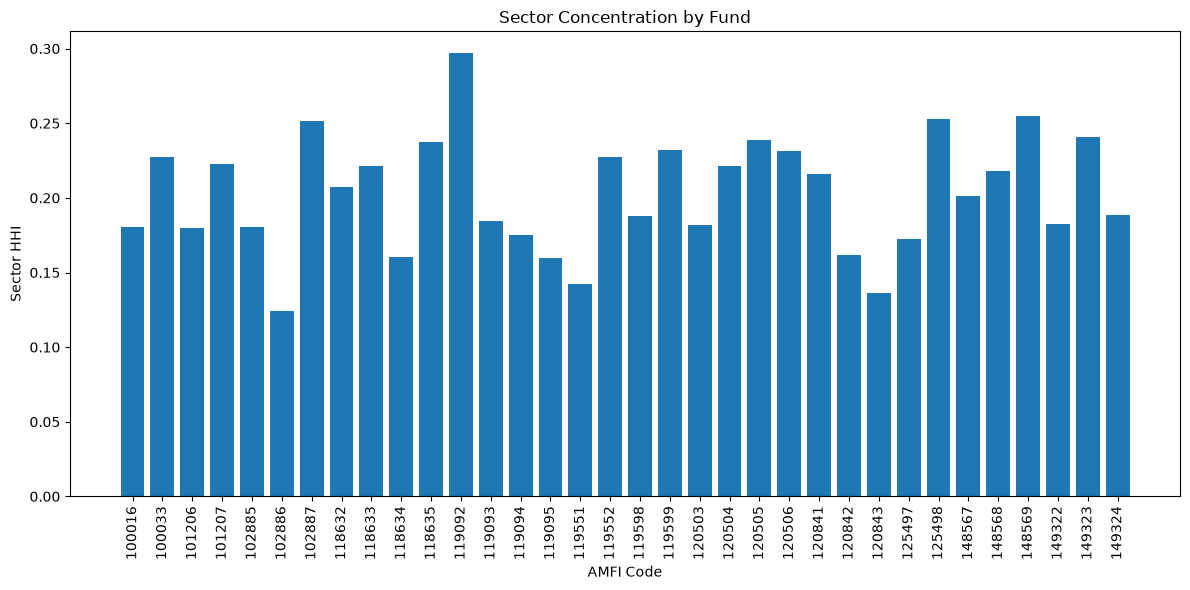

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    sector_hhi["amfi_code"].astype(str),
    sector_hhi["sector_hhi"]
)

plt.xlabel("AMFI Code")
plt.ylabel("Sector HHI")
plt.title("Sector Concentration by Fund")

plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    "../reports/charts/sector_hhi_chart.png",
    dpi=300
)

plt.show()

# Advanced Analytics Summary

1. VaR/CVaR Risk: Fund 119599 showed the highest downside risk, with a 95% VaR of -2.69%** and CVaR of -3.24%. This indicates higher potential losses during extreme negative-return periods.

2. Rolling Sharpe Performance: Fund 120841 recorded the highest maximum 90-day rolling Sharpe ratio of 6.77, followed by funds 119551 (6.45) and 118632 (5.27). This indicates strong risk-adjusted performance during their best rolling periods.

3. Investor Cohort Analysis: The 2024 cohort recorded total transaction value of approximately ₹349.11 crore, compared with approximately ₹3.05 crore for the 2025 cohort. Fund 148568 was the preferred fund for the 2024 cohort, with 874 transactions.

4. SIP Continuation Risk: Among investors with at least 6 SIP transactions, 1,332 investors were classified as at-risk, compared with only 30 regular investors. This suggests a significant SIP continuation and retention risk.

5. Sector Concentration: Fund 102887 had a relatively high sector HHI of 0.2514, indicating higher sector concentration, while fund 102886 had a low HHI of 0.1240, indicating better sector diversification.

The advanced analytics show that mutual fund risk and investor behavior vary significantly across funds and investor cohorts. VaR/CVaR identifies downside risk, rolling Sharpe highlights risk-adjusted performance, cohort analysis shows investment behavior, SIP continuity identifies retention risk, and sector HHI highlights portfolio concentration.
